# **Imports**

In [1]:
!pip install pmdarima
!pip install git+https://github.com/scikit-learn-contrib/py-earth@v0.2dev

     |████████████████████████████████| 1.5 MB 4.1 MB/s 
     |████████████████████████████████| 9.5 MB 13.5 MB/s 
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2
  Cloning https://github.com/scikit-learn-contrib/py-earth (to revision v0.2dev) to /tmp/pip-req-build-uzf35qju
  Running command git clone -q https://github.com/scikit-learn-contrib/py-earth /tmp/pip-req-build-uzf35qju
  Running command git checkout -b v0.2dev --track origin/v0.2dev
  Switched to a new branch 'v0.2dev'
  Branch 'v0.2dev' set up to track remote branch 'v0.2dev' from 'origin'.
  Created wheel for sklearn-contrib-py-earth: filename=sklearn_contrib_py_earth-0.1.0+16.g400f84d-cp37-cp37m-linux_x86_64.whl size=3997356 sha256=66e10b3ae45b18f435c4c6d14075e8bb7dc383ef5333278eff9fb003d927b3fd
  Stored in directory: /tmp/pip-ephem-wheel-cache-ynpibeci/wheels/79/d7/aa/1e418a9aea84424ef2ce2697ae7c

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import datetime
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import sklearn
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots  import plot_acf as pltacf
from  statsmodels.tsa.stattools import pacf as PACF
from statsmodels.graphics.tsaplots  import plot_pacf as pltpacf
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [3]:
!gdown --id 1OhcEyfh8Og_-jbQxFVrjw8qkoCOVyI-3

Downloading...
From: https://drive.google.com/uc?id=1OhcEyfh8Og_-jbQxFVrjw8qkoCOVyI-3
To: /content/M&M.NS.csv
100% 155k/155k [00:00<00:00, 51.9MB/s]


In [4]:
stock_name="M&M"

In [5]:
df_stock = pd.read_csv('M&M.NS.csv',index_col='Date')
df_stock.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,635.974976,639.724976,630.000000,632.674988,486818.0,4,1,1,7791.299805,9.724976
2016-01-04,631.500000,631.500000,619.849976,621.250000,727368.0,0,4,1,7784.649902,11.650024
2016-01-05,623.000000,635.950012,619.849976,624.599976,1466066.0,1,5,1,7741.000000,16.100037
2016-01-06,620.049988,624.099976,610.000000,613.075012,1178150.0,2,6,1,7568.299805,14.099976
2016-01-07,609.500000,609.525024,587.500000,598.724976,1954754.0,3,7,1,7601.350098,22.025024


#**ARIMA - Autoregression Intergrated Moving Average**

##*Decomposing the data*

In [6]:
df_stock['Close'].head()

Date
2016-01-01    632.674988
2016-01-04    621.250000
2016-01-05    624.599976
2016-01-06    613.075012
2016-01-07    598.724976
Name: Close, dtype: float64

Text(0.5, 1.0, 'Close Price - M&M')

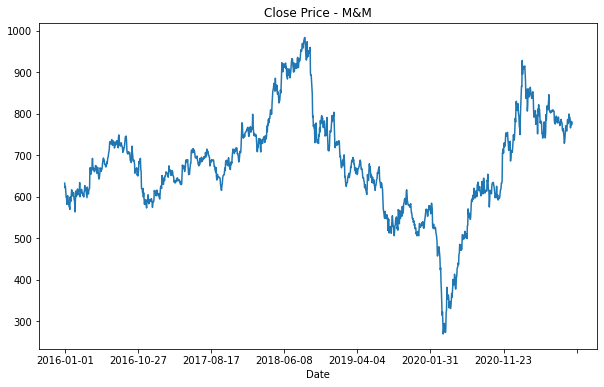

In [7]:
plt.rcParams['figure.figsize'] = (10,6)
df_stock['Close'].plot()
plt.title("Close Price - "+stock_name)

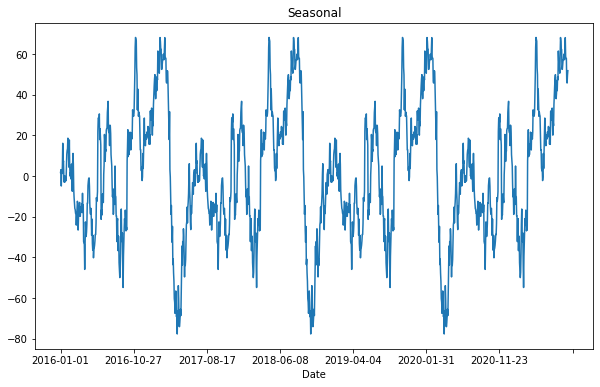

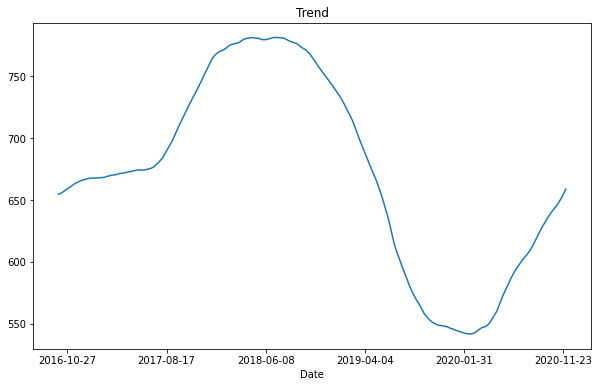

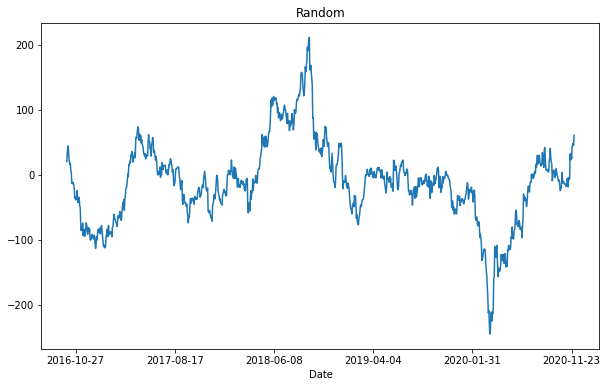

In [8]:
plt.rcParams['figure.figsize'] = (10,6)
decomposition=seasonal_decompose(df_stock['Close'],freq=365)
decomposition.seasonal.plot()
plt.title("Seasonal")
plt.show()
decomposition.trend.plot()
plt.title("Trend")
plt.show()
decomposition.resid.plot()
plt.title("Random")
plt.show()

##*Stationary Check*

In [9]:
Stationary=False
dvalue=0
Stationary_df=df_stock['Close'].copy()
while(Stationary==False):
  dftest = adfuller(Stationary_df.dropna(),autolag='AIC')
  dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
  for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
  print(dftest[1])
  if (dftest[1]>0.05):
    Stationary=False
    Stationary_df = Stationary_df - Stationary_df.shift(1)
  else :
    Stationary=True
  dvalue+=1  
print(dfoutput)
print("Differencing Value : ",dvalue)

0.29364899896925734
2.617645518699789e-28
Test Statistic                -1.547265e+01
p-value                        2.617646e-28
#lags used                     4.000000e+00
number of observations used    1.382000e+03
critical value (1%)           -3.435091e+00
critical value (5%)           -2.863634e+00
critical value (10%)          -2.567885e+00
dtype: float64
Differencing Value :  2


##*ACF*

In [10]:
from  statsmodels.tsa.stattools import acf as ACF
ACFOutput = ACF(Stationary_df.dropna(),nlags=20)
print(ACFOutput)

[ 1.         -0.04831895  0.0394441  -0.04235194  0.04344099  0.05145454
 -0.01918495  0.02258067 -0.01436852 -0.00331767 -0.01576707 -0.03451046
 -0.0029287  -0.04163693  0.05679326 -0.05513538  0.05874611  0.02883366
  0.02603163 -0.032639    0.02372558]


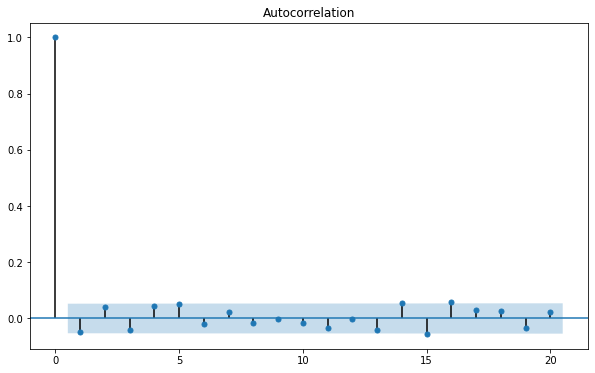

In [11]:
plt.rcParams['figure.figsize'] = (10,6)
pltacf(Stationary_df.dropna(),lags=20)
plt.show()

##*PACF*

In [12]:
PACFOutput = PACF(Stationary_df.dropna(),nlags=20)
print(PACFOutput)

[ 1.         -0.04835381  0.03725006 -0.03894867  0.0385711   0.05871529
 -0.01912302  0.02044164 -0.00846642 -0.01235534 -0.01544599 -0.03677908
 -0.0074345  -0.03891027  0.05322064 -0.0439833   0.05295816  0.04621997
  0.0224182  -0.0332472   0.02624142]


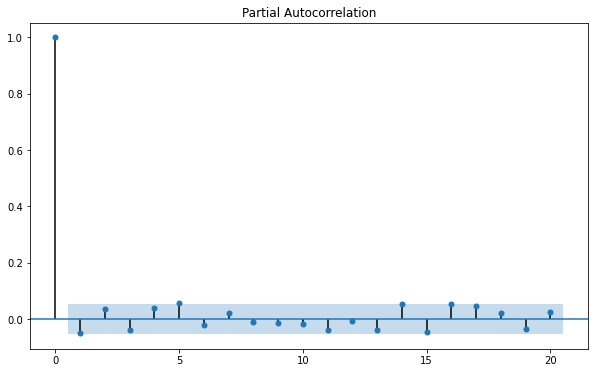

In [13]:
plt.rcParams['figure.figsize'] = (10,6)
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

##*Test and Train Split*

In [14]:
df_stock_train=df_stock.loc['2016-01-01':'2021-07-31']['Close']
df_stock_test=df_stock.loc['2021-07-31':]['Close']

In [15]:
df_stock_train.tail()

Date
2021-07-26    754.299988
2021-07-27    745.549988
2021-07-28    728.700012
2021-07-29    731.450012
2021-07-30    743.099976
Name: Close, dtype: float64

In [16]:
df_stock_test.head()

Date
2021-08-02    757.700012
2021-08-03    770.849976
2021-08-04    766.250000
2021-08-05    759.349976
2021-08-06    758.250000
Name: Close, dtype: float64

##*Model Fitting*

In [17]:
arima_model=auto_arima(df_stock_train,seasonal=False,max_p=2,max_d=2,max_q=2,start_p=0,start_q=0,d=1)

In [18]:
arima_model

ARIMA(maxiter=50, method='lbfgs', order=(2, 1, 2), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=False)

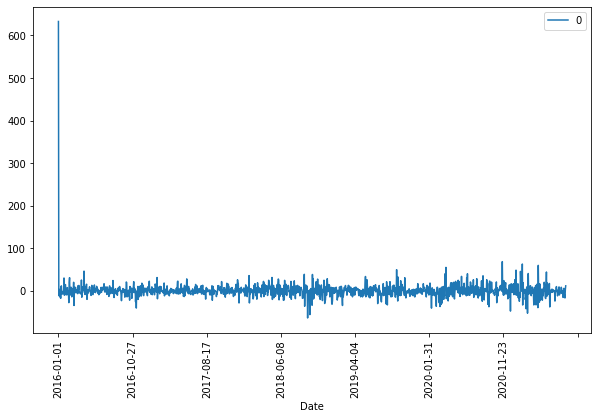

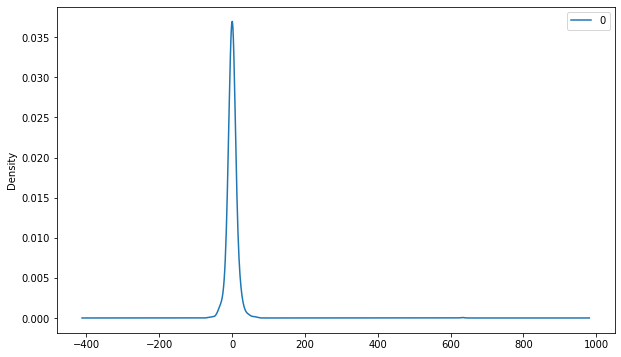

                 0
count  1369.000000
mean      0.542805
std      21.207306
min     -63.850037
25%      -6.424988
50%       0.125000
75%       6.250000
max     632.674988


In [19]:
model = ARIMA(df_stock_train, order=(0,1,0))
model_fit = model.fit()
residuals = pd.DataFrame(model_fit.resid)
plt.rcParams['figure.figsize'] = (10,6)
residuals.plot()
plt.xticks(rotation=90)
plt.show()
residuals.plot(kind='kde')
plt.show()
print(residuals.describe())

##*Forecasting and Testing*

In [20]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values)):
    model = ARIMA(history, order=(0,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)
error = np.sqrt(mean_squared_error(df_stock_test.values, predictions))
print('Test Error Percentage',(error/np.mean(df_stock_test.values))*100)

Test Error Percentage 1.377501173958318


([], <a list of 0 Text major ticklabel objects>)

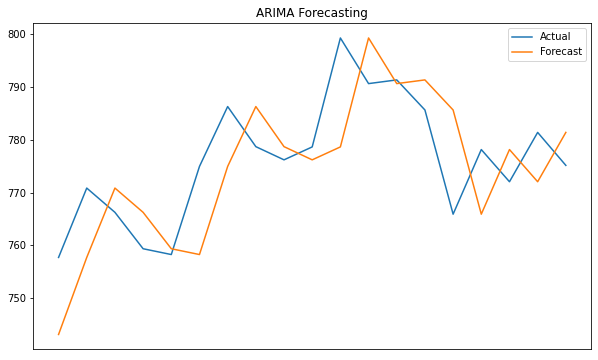

In [21]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(df_stock_test, label='Actual')
plt.plot(predictions, label='Forecast')
plt.title('ARIMA Forecasting')
plt.legend()
plt.xticks([])

##*Forecast for August*

In [22]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values[:14])):
    model = ARIMA(history, order=(0,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)

In [23]:
predictions

[743.0999755859375,
 757.7000122070312,
 770.8499755859375,
 766.25,
 759.3499755859375,
 758.25,
 774.9500122070312,
 786.2999877929688,
 778.7000122070312,
 776.2000122070312,
 778.6500244140625,
 799.2999877929688,
 790.6500244140625,
 791.3499755859375]

#**MARS - Multivariate Adaptive Regression Splines**

In [24]:
from pyearth import Earth

In [25]:
df_stock_mars_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:5].copy()
df_stock_mars_test=df_stock.loc['2021-07-31':].iloc[:,:5].copy()

In [26]:
df_stock_mars_train.shape

(1369, 5)

In [27]:
df_stock_mars_test.shape

(19, 5)

In [28]:
df_stock_mars_train.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-01-01,635.974976,639.724976,630.000000,632.674988,486818.0
2016-01-04,631.500000,631.500000,619.849976,621.250000,727368.0
2016-01-05,623.000000,635.950012,619.849976,624.599976,1466066.0
2016-01-06,620.049988,624.099976,610.000000,613.075012,1178150.0
2016-01-07,609.500000,609.525024,587.500000,598.724976,1954754.0


In [29]:
df_stock_mars_test

,Open,High,Low,Close,Volume
Date,,,,,
2021-08-02,750.000000,759.049988,744.599976,757.700012,2260861.0
2021-08-03,763.400024,772.700012,755.500000,770.849976,3235393.0
2021-08-04,773.000000,775.799988,764.549988,766.250000,2659372.0
2021-08-05,766.000000,766.349976,756.700012,759.349976,1451370.0
2021-08-06,763.799988,772.299988,755.000000,758.250000,4471604.0
2021-08-09,762.000000,782.000000,761.500000,774.950012,6700633.0
2021-08-10,776.950012,789.799988,775.150024,786.299988,4724852.0
2021-08-11,786.299988,789.950012,767.500000,778.700012,3147983.0
2021-08-12,781.000000,794.650024,773.750000,776.200012,3551026.0


In [30]:
x_train_mars = df_stock_mars_train.drop(['Close'], axis=1)
y_train_mars = df_stock_mars_train['Close']
x_test_mars = df_stock_mars_test.drop(['Close'], axis=1)
y_test_mars = df_stock_mars_test['Close']

##*Fitting the model*

In [31]:
MARS_model = Earth(max_terms = 600,max_degree=3)
MARS_model_fitted = MARS_model.fit(x_train_mars, y_train_mars)
y_pred_mars = MARS_model_fitted.predict(x_test_mars[:14])

##*Evaluating the model*

In [32]:
MSE = mean_squared_error(y_test_mars[:14], y_pred_mars)
RMSE = np.sqrt(MSE)
RMSE_mean = (RMSE/np.mean(y_test_mars[:14]))*100
print("RMSE Score :", round(RMSE, 2))
print("RMSE/Mean", round(RMSE_mean,1))

RMSE Score : 4.12
RMSE/Mean 0.5


##*Plotting Forecast vs Actual* 

([], <a list of 0 Text major ticklabel objects>)

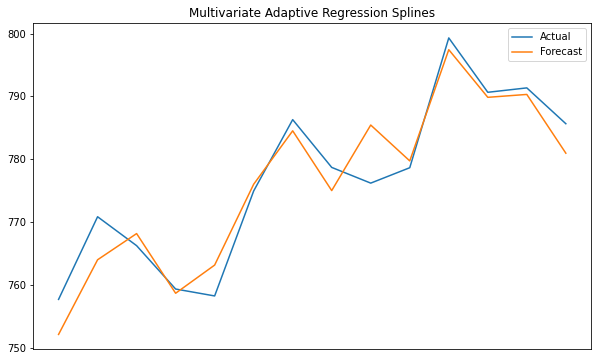

In [33]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(y_test_mars[:14], label='Actual')
plt.plot(y_pred_mars, label='Forecast')
plt.title('Multivariate Adaptive Regression Splines')
plt.legend()
plt.xticks([])

#**VAR - Vector Autoregression**

In [34]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

In [35]:
df_stock_var = df_stock.loc['2016-01-01':'2021-08-20'].iloc[:,:4].copy()
df_stock_var_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:4].copy()
df_stock_var_test=df_stock.loc['2021-07-31':'2021-08-20'].iloc[:,:4].copy()


In [36]:
df_stock_var_train.shape

(1369, 4)

In [37]:
df_stock_var_test.shape

(14, 4)

In [38]:
df_stock_var.shape

(1383, 4)

##*Plotting the Data*

In [39]:
fig, axes = plt.subplots(nrows=4, ncols=1, dpi=120, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df_stock_var[df_stock_var.columns[i]]
    ax.plot(data, linewidth=1)
    # Decorations
    ax.set_title(df_stock_var.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout()

##*Granger Causality Test*

In [40]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

grangers_causation_matrix(df_stock_var, variables = df_stock_var.columns)        

,Open_x,High_x,Low_x,Close_x
Open_y,1.0000,0.0000,0.0000,0.0
High_y,0.0000,1.0000,0.0000,0.0
Low_y,0.0000,0.0000,1.0000,0.0
Close_y,0.0098,0.1103,0.0001,1.0


##*Cointegration Test*

In [41]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df_stock_var, alpha=0.05): 
    out = coint_johansen(df_stock_var,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    print('Name   ::  Test Statistic > C(95%)    =>   Significance  \n', '--'*20)
    for col, trace, cvt in zip(df_stock_var.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df_stock_var)

Name   ::  Test Statistic > C(95%)    =>   Significance  
 ----------------------------------------
Open   ::  455.75    > 40.1749   =>   True
High   ::  229.12    > 24.2761   =>   True
Low    ::  76.92     > 12.3212   =>   True
Close  ::  0.0       > 4.1296    =>   False


##*ADF Test*

In [42]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")    

In [43]:
# ADF Test on each column
for name, column in df_stock_var_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -1.7796
 No. Lags Chosen       = 1
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.3907. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -1.8301
 No. Lags Chosen       = 1
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.3656. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit roo

##*ADF Test on first order differencing*

In [44]:
df_differenced = df_stock_var_train.diff().dropna()

In [45]:
# ADF Test on each column of 1st Differences Dataframe
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -39.534
 No. Lags Chosen       = 0
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -33.6445
 No. Lags Chosen       = 0
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05


##*Selecting the number of lags*

In [46]:
model = VAR(df_differenced)
x = model.select_order(maxlags=20)
x.summary()

,AIC,BIC,FPE,HQIC
0,17.68,17.69,4.763e+07,17.68
1,15.86,15.94,7.733e+06,15.89
2,15.32,15.46,4.511e+06,15.37
3,15.10,15.30,3.609e+06,15.17
4,14.98,15.24,3.192e+06,15.07
5,14.91,15.23*,2.977e+06,15.03
6,14.86,15.25,2.854e+06,15.01*
7,14.84,15.29,2.797e+06,15.01
8,14.83,15.34,2.759e+06,15.02
9,14.81,15.38,2.702e+06,15.02


##*Fitting the model*

In [47]:
model_fitted = model.fit(x.aic)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 15, Sep, 2021
Time:                     15:57:08
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    15.8199
Nobs:                     1351.00    HQIC:                   15.1543
Log likelihood:          -17359.5    FPE:                2.56180e+06
AIC:                      14.7559    Det(Omega_mle):     2.09900e+06
--------------------------------------------------------------------
Results for equation Open
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.022151         0.133320            0.166           0.868
L1.Open          -1.028098         0.036521          -28.151           0.000
L1.High           0.042198         0.029906            1.411           0.158


##*Durbin Watson Test*

In [48]:
from statsmodels.stats.stattools import durbin_watson
out = durbin_watson(model_fitted.resid)

for col, val in zip(df_stock_var.columns, out):
    print(col, ':', round(val, 2))

Open : 2.0
High : 1.99
Low : 1.99
Close : 2.0


##*Getting the Forecast*

In [49]:
# Get the lag order
lag_order = model_fitted.k_ar
print(lag_order)

# Input data for forecasting
forecast_input = df_differenced.values[-lag_order:]
forecast_input

17


array([[-12.79998779, -13.09997559, -10.15002441,  -3.        ],
       [  0.15002441,   5.69995117,   2.45001221,  -2.65002441],
       [ -5.95001221, -11.59997559,  -4.        ,  -4.70001221],
       [  4.        ,   5.        ,   1.5       ,   1.29998779],
       [  1.90002441,   1.20001221,   5.15002441,   8.30004883],
       [  2.09997559,   4.79998779,   3.39996338,   5.        ],
       [  1.        ,  -3.04998779,  -1.84997559,  -6.25      ],
       [  3.        ,   0.04998779,   1.29998779,  -0.10003662],
       [ -8.20001221,  -3.29998779,  -6.5       ,  -4.        ],
       [ -0.79998779,  -5.        , -17.65002441, -15.59997559],
       [-10.79998779,  -8.60003662,   3.30004883,  -1.75      ],
       [ -5.70001221,   0.75      ,   2.59997559,   5.75      ],
       [  4.5       ,  -3.75      ,  -5.75      ,  -9.90002441],
       [ -7.        ,  -4.09997559,  -9.84997559,  -8.75      ],
       [ -5.29998779,  -9.29998779, -18.        , -16.84997559],
       [-20.70001221, -11

In [50]:
nobs = 14
fc = model_fitted.forecast(y=forecast_input, steps=nobs)
df_forecast = pd.DataFrame(fc, index=df_stock_var.index[-nobs:], columns=df_stock_var.columns + '_1d')
df_forecast

,Open_1d,High_1d,Low_1d,Close_1d
Date,,,,
2021-08-02,9.671704,-5.691999,5.385283,1.795115
2021-08-03,2.296089,1.256633,3.879890,2.095511
2021-08-04,1.965326,1.424713,-1.680323,-0.438609
2021-08-05,-0.351982,0.640873,3.489117,2.025312
2021-08-06,2.892707,2.206476,2.088281,4.001652
2021-08-09,1.899563,0.782244,1.208366,0.787074
2021-08-10,2.623079,2.073124,2.514541,0.825985
2021-08-11,2.069924,2.981670,0.901427,3.461498
2021-08-12,0.724374,-0.238435,3.037288,-0.064092


##*Inverting forecast back to original scale*

In [51]:
def invert_transformation(df_train, df_forecast, first_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:        
        if first_diff:
          # Roll back 1st Diff
          df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [52]:
df_results = invert_transformation(df_stock_var_train, df_forecast, first_diff=True)        
df_results.loc[:, ['Open_forecast','High_forecast','Low_forecast','Close_forecast']]

,Open_forecast,High_forecast,Low_forecast,Close_forecast
Date,,,,
2021-08-02,744.871716,754.308001,737.235259,744.895091
2021-08-03,747.167805,755.564634,741.115149,746.990601
2021-08-04,749.133132,756.989346,739.434826,746.551992
2021-08-05,748.781150,757.630219,742.923943,748.577304
2021-08-06,751.673856,759.836694,745.012224,752.578956
2021-08-09,753.573420,760.618939,746.220589,753.366030
2021-08-10,756.196499,762.692063,748.735131,754.192015
2021-08-11,758.266423,765.673733,749.636558,757.653513
2021-08-12,758.990797,765.435298,752.673846,757.589422


##*Plotting Forecast vs Actual*

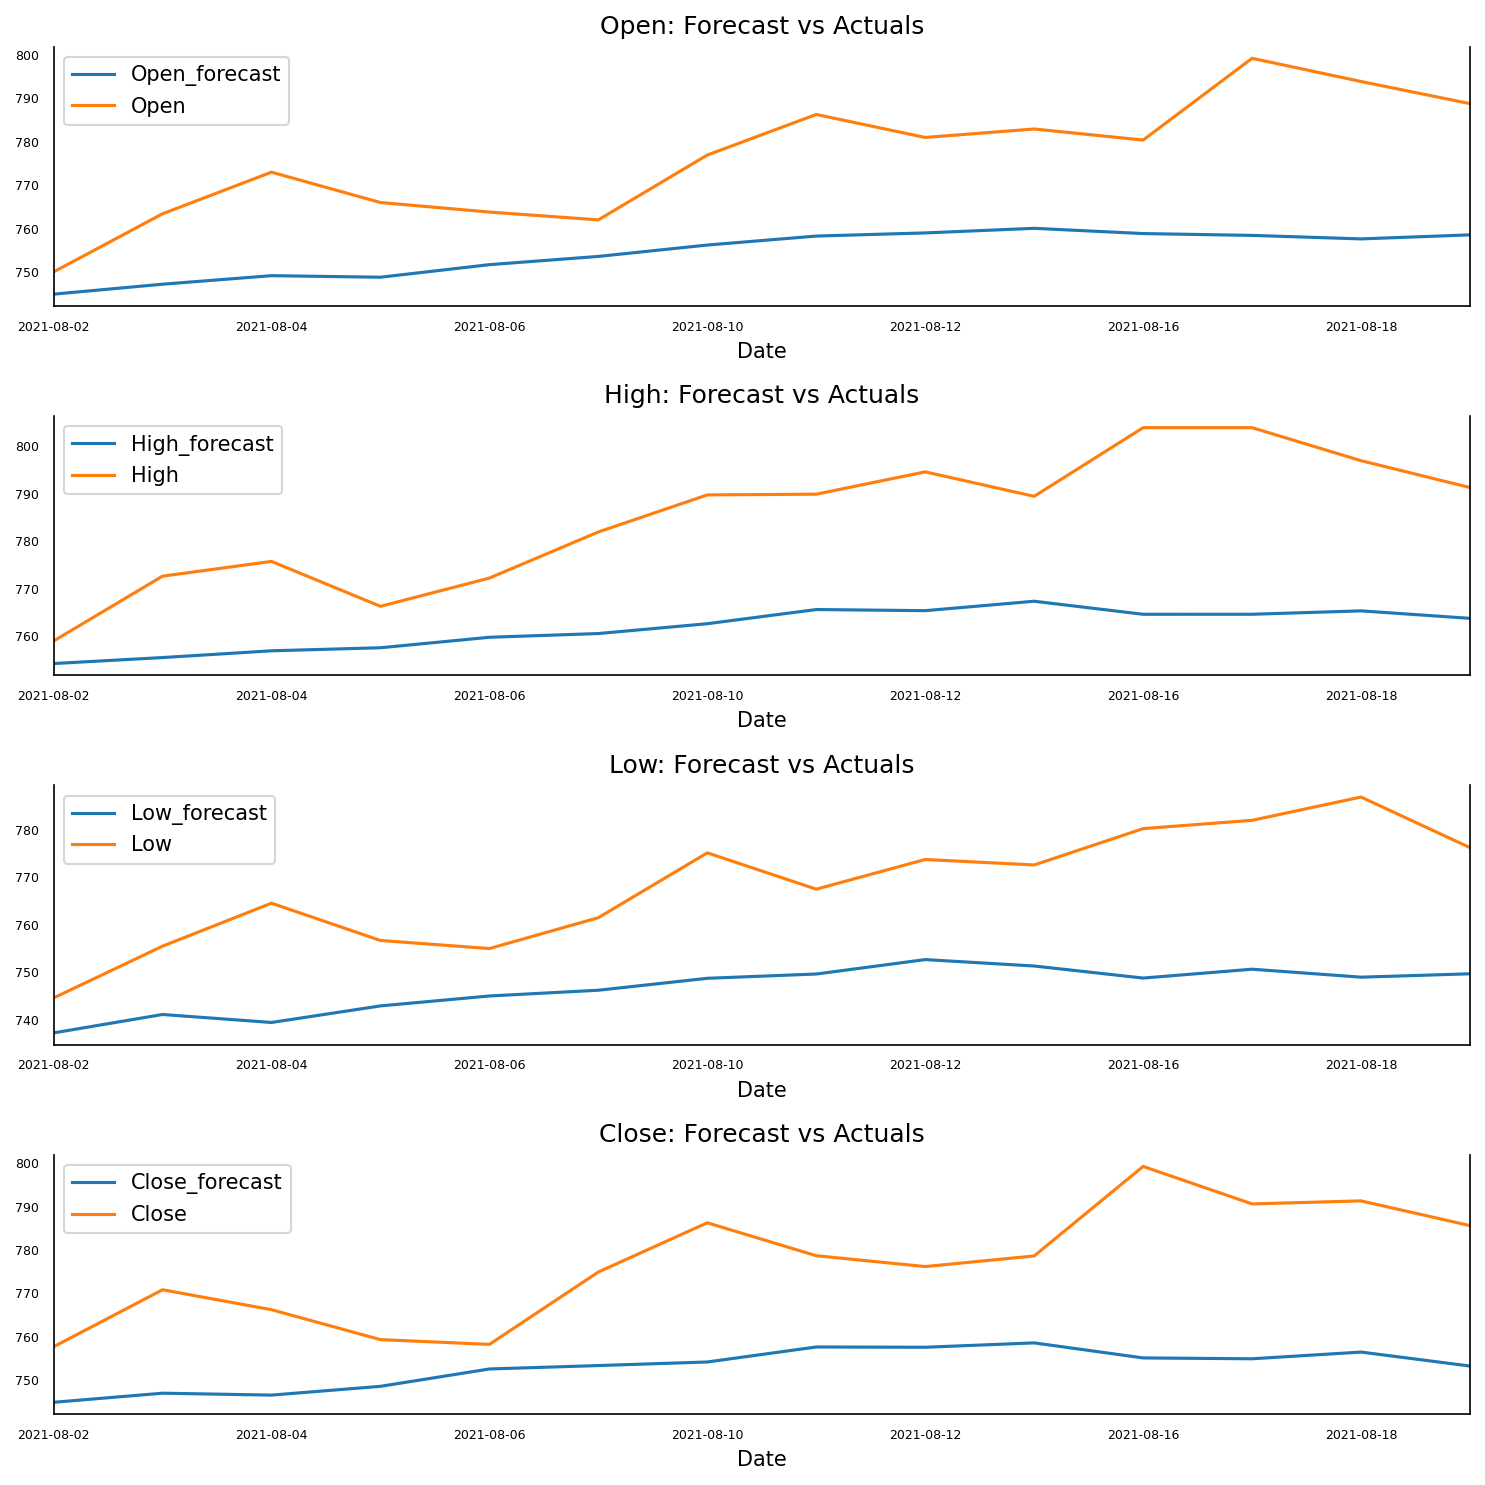

In [53]:
 fig, axes = plt.subplots(nrows=4, ncols=1, dpi=150, figsize=(10,10))
 for i, (col,ax) in enumerate(zip(df_stock_var.columns, axes.flatten())):
   df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
   df_stock_var_test[col][-nobs:].plot(legend=True, ax=ax);
   ax.set_title(col + ": Forecast vs Actuals")
   ax.xaxis.set_ticks_position('none')
   ax.yaxis.set_ticks_position('none')
   ax.spines["top"].set_alpha(0)
   ax.tick_params(labelsize=6)

plt.tight_layout();

##*Evaluating the model*

In [54]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual): 
    rmse = np.mean((forecast - actual)**2)**.5  
    rmse_p = (rmse/np.mean(actual))*100
    return({'rmse':rmse,'rmse_mean':rmse_p})

print('Forecast Accuracy of Open')
accuracy_prod = forecast_accuracy(df_results['Open_forecast'].values, df_stock_var_test['Open'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of High')
accuracy_prod = forecast_accuracy(df_results['High_forecast'].values, df_stock_var_test['High'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Low')
accuracy_prod = forecast_accuracy(df_results['Low_forecast'].values, df_stock_var_test['Low'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Close')
accuracy_prod = forecast_accuracy(df_results['Close_forecast'].values, df_stock_var_test['Close'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))



Forecast Accuracy of Open
rmse :  23.8501
rmse_mean :  3.0724

Forecast Accuracy of High
rmse :  25.1642
rmse_mean :  3.2061

Forecast Accuracy of Low
rmse :  23.0619
rmse_mean :  3.0028

Forecast Accuracy of Close
rmse :  25.9814
rmse_mean :  3.345


#**Linear Regression**

In [55]:
df_stock_train_lin=df_stock.loc['2016-01-01':'2021-07-31'].copy()
df_stock_test_lin=df_stock.loc['2021-07-31':].copy()


##*Normalize the data*

In [56]:
from sklearn.preprocessing import MinMaxScaler

In [57]:
scaler = MinMaxScaler()
df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.fit_transform(df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])
df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.transform(df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])

In [58]:
df_stock_train_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,0.516354,0.502430,0.525051,632.674988,0.004180,4,1,1,0.091661,0.060774
2016-01-04,0.510152,0.490845,0.511194,621.250000,0.011551,0,4,1,0.090919,0.079419
2016-01-05,0.498372,0.497113,0.511194,624.599976,0.034185,1,5,1,0.086044,0.122518
2016-01-06,0.494283,0.480423,0.497747,613.075012,0.025363,2,6,1,0.066755,0.103147
2016-01-07,0.479662,0.459894,0.467031,598.724976,0.049159,3,7,1,0.070447,0.179903


In [59]:
df_stock_test_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2021-08-02,0.674382,0.670493,0.681502,757.700012,0.058539,0,2,8,1.023069,0.106538
2021-08-03,0.692953,0.689718,0.696382,770.849976,0.088399,1,3,8,1.037370,0.133172
2021-08-04,0.706257,0.694084,0.708737,766.250000,0.070749,2,4,8,1.041369,0.075545
2021-08-05,0.696556,0.680775,0.698020,759.349976,0.033735,3,5,8,1.035070,0.060048
2021-08-06,0.693507,0.689155,0.695700,758.250000,0.126278,4,6,8,1.037309,0.134140


##*Checking for multicollinearity*

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor    

def calculate_vif_(X, thresh=10,verbose=True):
    cols = X.columns
    variables = np.arange(X.shape[1])
    dropped=True
    while dropped:
        dropped=False
        c = X[cols[variables]].values
        vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]
        

        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            if verbose == True:
                print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
            variables = np.delete(variables, maxloc)
            dropped=True
    if verbose == True:
        print('Remaining variables:')
        print(X.columns[variables])
    return X[cols[variables]]

##*Model Generation*

In [61]:
def forward_regression(X, y,
                       threshold_in,
                       verbose=False):
    initial_list = []
    included = list(initial_list)
    while True:
        changed=False
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        if not changed:
            break

    return included

In [62]:
def backward_regression(X, y,
                           threshold_out,
                           verbose=False):
    included=list(X.columns)
    while True:
        changed=False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() 
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [63]:
def model_generator(df_train,df_test):
    train_dummy=pd.get_dummies(df_train,columns=['Day of Week','Day of Month','Month'])
    test_dummy = pd.get_dummies(df_test,columns=['Day of Week','Day of Month','Month'])
    for i in [1,2,3,4,5,6,7,9,10,11,12]:
        test_dummy['Month_'+str(i)] = 0
        test_dummy['Month_'+str(i)] = test_dummy['Month_'+str(i)].astype('uint8')
    for i in range(1,32):
      if (i not in df_test['Day of Month'].unique()):
        test_dummy['Day of Month_'+str(i)] = 0
        test_dummy['Day of Month_'+str(i)] = test_dummy['Day of Month_'+str(i)].astype('uint8')   
    X=train_dummy.drop('Close',axis=1)
    y=train_dummy["Close"]
    X_f=calculate_vif_(X.select_dtypes(exclude='uint8'),10,False)
    X_f=pd.concat([X_f,X.iloc[:,6:]],axis=1)
    model=sm.OLS(y,X_f[backward_regression(X_f,y,0.01)],axis=1).fit()
    pred=model.predict(test_dummy[backward_regression(X_f,y,0.01)])
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(test_dummy['Close'], pred))
    rmse_pct= (rmse/np.mean(test_dummy['Close']))*100
    sig_var = model.pvalues.index.tolist()
    return model,sig_var,rmse_pct    

In [64]:
 model,variables,rmse_per = model_generator(df_stock_train_lin,df_stock_test_lin)

In [65]:
print(model.summary2())

                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.991     
Dependent Variable: Close            AIC:                10582.6680
Date:               2021-09-15 15:57 BIC:                10681.8828
No. Observations:   1369             Log-Likelihood:     -5272.3   
Df Model:           18               F-statistic:        8556.     
Df Residuals:       1350             Prob (F-statistic): 0.00      
R-squared:          0.991            Scale:              131.44    
-------------------------------------------------------------------
                 Coef.   Std.Err.    t     P>|t|   [0.025   0.975] 
-------------------------------------------------------------------
Open            719.3622   1.9903 361.4279 0.0000 715.4577 723.2666
Volume           33.9862   4.7630   7.1355 0.0000  24.6426  43.3298
Range           -12.4557   4.0822  -3.0513 0.0023 -20.4638  -4.4477
Day of Week_0   184.0689   1.0818 170.1478 0.0000 181.9466 186.191

In [66]:
print("Significance Variables :",'\n',*variables,sep='\n')

Significance Variables :


Open
Volume
Range
Day of Week_0
Day of Week_1
Day of Week_2
Day of Week_3
Day of Week_4
Month_1
Month_2
Month_3
Month_4
Month_5
Month_6
Month_7
Month_8
Month_9
Month_10
Month_11
Month_12


In [67]:
print("RMSE Percentage",rmse_per,sep='\n')

RMSE Percentage
1.2443872593796361
